# 4.2 Demand Prediction

In this notebook we implement Neural Networks (NNs) to predict taxi trip demand in chicago. Additionally, we compare the performances of the NNs across different complexity levels.

For NNs there are 2 "main" complexity interpretations:
- depth: number of hidden layers
- width: number of nodes per layer
- (more complex activation function) - maybe as an extra
- (more complex optimizer) - maybe as an extra

So we decide to test 3 different NN structures:

__baseline model__:
- hidden layers: 2
- nodes per layer: 64

__wider model__:
- hidden layers: 2
- nodes per layer: 256

__deeper model__:
- hidden layers: 8
- nodes per layer: 64

For better comparison, we will test all three architectures with the same shared configurations.

Before training any NN, we establish two simple **benchmarks** to contextualise the results:

1. **Historical-mean predictor** — for each hexagon × hour-of-day pair, predict the mean `trip_count` seen in the training set. Unseen combinations fall back to the global training mean. This captures the dominant demand pattern (location + time-of-day) without any learning.
2. **Ridge regression** — a linear model fit on the same scaled feature matrix. Trained on log₁⁺ demand and back-transformed at evaluation time (same target encoding as the NNs). This shows how much a linear model can do before adding any non-linearity or depth.

## Table of Contents

- [4.2.1 Data Information](#421-data-information)
- [4.2.2 Model Configurations](#422-model-configurations)
- [4.2.3 Model Definition](#423-model-definition)
- [4.2.4 Hyperparameter Search Definition (GridSearch)](#424-hyperparameter-search-definition-gridsearch)
- [4.2.5 Visualization: Model Architecture](#425-visualization-model-architecture)
- [4.2.6 Train / Val / Test Split](#426-train--val--test-split)
- [4.2.7 Feature Preparation](#427-feature-preparation)
- [4.2.8 Benchmark Models](#428-benchmark-models)
- [4.2.9 Baseline Model — Training](#429-baseline-model--training)
  - [4.2.9 Baseline Model — Evaluation](#429-baseline-model--evaluation)
- [4.2.10 Hyperparameter Search — Baseline Model](#4210-hyperparameter-search--baseline-model)
  - [4.2.10 Tuned Baseline — Training](#4210-tuned-baseline--training)
  - [4.2.10 Tuned Baseline — Evaluation](#4210-tuned-baseline--evaluation)
- [4.2.11 Deeper Model — Training](#4211-deeper-model--training)
  - [4.2.11 Deeper Model — Evaluation](#4211-deeper-model--evaluation)
- [4.2.12 Hyperparameter Search — Deeper Model](#4212-hyperparameter-search--deeper-model)
  - [4.2.12 Wider Model — Training](#4212-wider-model--training)
  - [4.2.12 Wider Model — Evaluation](#4212-wider-model--evaluation)
  - [4.2.12 Hyperparameter Search — Wider Model](#4212-hyperparameter-search--wider-model)
  - [4.2.12 Tuned Wider — Training](#4212-tuned-wider--training)
  - [4.2.12 Tuned Wider — Evaluation](#4212-tuned-wider--evaluation)

In [147]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Import packages                         #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import pandas as pd
# import matplotlib.pyplot as plt

# modeling
import copy
import random
import types
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score as _r2

# evaluation
import datetime
from tqdm.auto import tqdm as _tqdm

# visualization
from torchinfo import summary
import matplotlib.pyplot as plt

# reset working dir
import os
from pathlib import Path


In [148]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/anthony/Documents/Dokumente – MacBook Pro von Anthony/UNI/AAA/AAA_TA_2026


In [149]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Load data                               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data = pd.read_parquet("data/aggregated/hexagon/demand_hex_1h_low.parquet")

In [150]:
data

,time_bucket,bucket_index,pickup_h3_res6,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01 00:00:00,482136,862664197ffffff,residential,0,0,0.0,0.000,0.000000,0.000000,...,3.463863,5.190882,0.000000,0.412471,0.219985,0.000000,0.000000,0.000000,0.027498,0.659954
1,2025-01-01 00:00:00,482136,86266419fffffff,residential,0,0,0.0,0.000,0.000000,0.000000,...,0.770790,5.836479,0.055042,0.137605,0.055042,0.055042,0.000000,0.000000,0.027521,0.330253
2,2025-01-01 00:00:00,482136,8626641b7ffffff,residential,0,0,0.0,0.000,0.000000,0.000000,...,3.428506,4.626667,0.027470,0.247232,0.027470,0.000000,0.000000,0.000000,0.000000,0.302173
3,2025-01-01 00:00:00,482136,862664527ffffff,airport,3,3,0.0,1228.000,9.536667,25.916667,...,2.529989,4.162891,0.027462,0.631634,0.302086,0.000000,0.000000,0.000000,0.000000,0.961182
4,2025-01-01 00:00:00,482136,86266452fffffff,residential,0,0,0.0,0.000,0.000000,0.000000,...,2.695998,5.548927,0.054970,0.659643,0.137426,0.384792,0.054970,0.027485,0.027485,1.346772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289075,2025-12-31 23:00:00,490895,862664dafffffff,residential,0,0,0.0,0.000,0.000000,0.000000,...,3.960234,4.291273,0.000000,0.027329,0.000000,0.000000,0.000000,0.000000,0.000000,0.027329
289076,2025-12-31 23:00:00,490895,862759347ffffff,airport,6,6,157.5,1481.500,15.505000,38.833333,...,2.892475,2.057285,0.136860,1.176998,0.301092,0.520069,0.000000,0.000000,0.027372,2.162392
289077,2025-12-31 23:00:00,490895,86275934fffffff,airport,8,8,165.0,1635.875,15.167500,38.625000,...,1.220338,2.809967,0.191761,1.068385,0.465706,0.383523,0.000000,0.000000,0.027394,2.136770
289078,2025-12-31 23:00:00,490895,86275935fffffff,airport,4,4,140.0,1582.750,13.910000,36.125000,...,1.340206,7.539746,0.054799,0.273996,0.054799,0.027400,0.000000,0.000000,0.000000,0.410994


## 4.2.1 Data Information

In [151]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Data Information                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# How many times does each row repeat when ignoring the time bucket?
# bucket_index is also excluded as it is a numeric encoding of the time bucket.
cols_no_time = [c for c in data.columns if c not in ('time_bucket', 'bucket_index')]
counts = data[cols_no_time].value_counts()

n_total    = len(data)
n_unique   = len(counts)
n_repeated = int((counts > 1).sum())

print(f"Total rows                    : {n_total:>10,}")
print(f"Unique combinations (no time) : {n_unique:>10,}")
print(f"Combinations appearing >1x    : {n_repeated:>10,}")
print(f"Avg repetitions per combo     : {n_total / n_unique:>10.2f}x")
print(f"\nRepetition count distribution:")
dist = counts.value_counts().sort_index()
for k, v in dist.items():
    print(f"  appears {k:>3}x : {v:>8,} combinations")

# How often does each hexagon + hour-of-day combination appear?
hex_hour_counts = data.groupby(['pickup_h3_res6', 'hour_of_day']).size()

print(f"\n--- Hexagon × Hour-of-day ---")
print(f"Unique hex × hour combinations : {len(hex_hour_counts):>8,}")
print(f"Avg appearances per combo      : {hex_hour_counts.mean():>8.1f}x")
print(f"Min appearances                : {hex_hour_counts.min():>8,}")
print(f"Max appearances                : {hex_hour_counts.max():>8,}")

# Zero-demand rows
n_zero        = int((data['trip_count'] == 0).sum())
pct_zero      = 100.0 * n_zero / n_total
print(f"\n--- Demand ---")
print(f"Zero-demand rows               : {n_zero:>8,}  ({pct_zero:.1f}%)")
print(f"Non-zero-demand rows           : {n_total - n_zero:>8,}  ({100 - pct_zero:.1f}%)")

Total rows                    :    289,080
Unique combinations (no time) :    289,080
Combinations appearing >1x    :          0
Avg repetitions per combo     :       1.00x

Repetition count distribution:
  appears   1x :  289,080 combinations

--- Hexagon × Hour-of-day ---
Unique hex × hour combinations :      792
Avg appearances per combo      :    365.0x
Min appearances                :      365
Max appearances                :      365

--- Demand ---
Zero-demand rows               :   91,126  (31.5%)
Non-zero-demand rows           :  197,954  (68.5%)


In [152]:
data.head()

,time_bucket,bucket_index,pickup_h3_res6,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01,482136,862664197ffffff,residential,0,0,0.0,0.0,0.000000,0.000000,...,3.463863,5.190882,0.000000,0.412471,0.219985,0.000000,0.00000,0.000000,0.027498,0.659954
1,2025-01-01,482136,86266419fffffff,residential,0,0,0.0,0.0,0.000000,0.000000,...,0.770790,5.836479,0.055042,0.137605,0.055042,0.055042,0.00000,0.000000,0.027521,0.330253
2,2025-01-01,482136,8626641b7ffffff,residential,0,0,0.0,0.0,0.000000,0.000000,...,3.428506,4.626667,0.027470,0.247232,0.027470,0.000000,0.00000,0.000000,0.000000,0.302173
3,2025-01-01,482136,862664527ffffff,airport,3,3,0.0,1228.0,9.536667,25.916667,...,2.529989,4.162891,0.027462,0.631634,0.302086,0.000000,0.00000,0.000000,0.000000,0.961182
4,2025-01-01,482136,86266452fffffff,residential,0,0,0.0,0.0,0.000000,0.000000,...,2.695998,5.548927,0.054970,0.659643,0.137426,0.384792,0.05497,0.027485,0.027485,1.346772


## 4.2.2 Model Configurations

In [153]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Shared Configs                          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# --- optimization ---
OPTIMIZER          = "adam"
LEARNING_RATE      = 5e-5
WEIGHT_DECAY       = 0.0     # decoupled L2 (AdamW); per-arch values come from the HP search
BATCH_SIZE         = 1024
MAX_EPOCHS         = 200

# --- loss / output ---
LOSS               = "nb_nll"  # "mse" | "mae" | "poisson_nll" | "nb_nll" (count NLLs: raw-count targets, log-rate output)
OUTPUT_UNITS       = 1
OUTPUT_ACTIVATION  = "softplus"

# --- layer defaults ---
HIDDEN_ACTIVATION  = "sigmoid"  # "relu" | "sigmoid"
WEIGHT_INIT        = "he_normal"

# --- early stopping ---
EARLY_STOPPING     = True
MONITOR            = "val_loss"
PATIENCE           = 10

# --- data handling ---
SPLIT              = "random"
SCALER_FIT_ON      = "train_only"

# --- hex embedding ---
HEX_EMBED_DIM      = 16      # learned embedding dim per hexagon

# --- device ---
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- reproducibility ---
SEEDS              = (0,)

# --- architectures ---
ARCH_BASELINE      = (2, 64)
ARCH_WIDER         = (2, 256)
ARCH_DEEPER        = (8, 64)

config = types.SimpleNamespace(
    LOSS           = LOSS,
    OPTIMIZER      = OPTIMIZER,
    HIDDEN_ACTIVATION = HIDDEN_ACTIVATION,
    LEARNING_RATE  = LEARNING_RATE,
    WEIGHT_DECAY   = WEIGHT_DECAY,
    BATCH_SIZE     = BATCH_SIZE,
    MAX_EPOCHS     = MAX_EPOCHS,
    EARLY_STOPPING = EARLY_STOPPING,
    PATIENCE       = PATIENCE,
    OUTPUT_UNITS   = OUTPUT_UNITS,
    HEX_EMBED_DIM  = HEX_EMBED_DIM,
)

ARCH_NAMES = {ARCH_BASELINE: "baseline", ARCH_WIDER: "wide", ARCH_DEEPER: "deep"}

HP_SEARCH_SEEDS        = (0,)
HP_PATIENCE            = 10
BEST_HP                = {}

HP_LR_CANDIDATES = []
HP_WD_CANDIDATES = [0.0]


## 4.2.3 Model Definition

In [154]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model + Training Utilities              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def nb_nll_loss(log_mu, y, log_theta):
    """NB2 negative log-likelihood: mean μ = exp(log_mu), Var = μ + μ²/θ, θ = exp(log_theta)."""
    theta   = torch.exp(log_theta)
    mu      = torch.exp(log_mu)
    log_t_m = torch.log(theta + mu)
    ll = (torch.lgamma(y + theta) - torch.lgamma(theta) - torch.lgamma(y + 1.0)
          + theta * (log_theta - log_t_m)
          + y     * (log_mu    - log_t_m))
    return -ll.mean()


class DemandBaseline(nn.Module):
    def __init__(self, input_dim, n_layers, width, n_hex, embed_dim):
        super().__init__()
        self.hex_embed = nn.Embedding(n_hex, embed_dim)
        nn.init.normal_(self.hex_embed.weight, std=0.01)

        _act_name = getattr(config, "HIDDEN_ACTIVATION", "relu").lower()
        _act_cls  = {"relu": nn.ReLU, "sigmoid": nn.Sigmoid}[_act_name]

        layers = []
        in_dim = input_dim + embed_dim
        for _ in range(n_layers):
            linear = nn.Linear(in_dim, width)
            if _act_name == "relu":
                nn.init.kaiming_normal_(linear.weight, nonlinearity="relu")
            else:
                nn.init.xavier_normal_(linear.weight)   # gain-matched for saturating activations
            nn.init.zeros_(linear.bias)
            layers += [linear, _act_cls()]
            in_dim = width
        out = nn.Linear(in_dim, config.OUTPUT_UNITS)
        nn.init.kaiming_normal_(out.weight, nonlinearity="relu")
        nn.init.zeros_(out.bias)
        layers.append(out)
        if getattr(config, "LOSS", "mse") not in ("poisson_nll", "nb_nll"):
            layers.append(nn.Softplus())   # output = log1p(y) estimate
        # else: output = unconstrained log-rate log(μ), consumed by the Poisson/NB NLL
        self.net = nn.Sequential(*layers)

        if getattr(config, "LOSS", "mse") == "nb_nll":
            # NB2 dispersion, trained jointly with the network weights
            self.log_theta = nn.Parameter(torch.zeros(()))

    def forward(self, x, hex_idx):
        emb = self.hex_embed(hex_idx)          # (batch, embed_dim)
        x   = torch.cat([x, emb], dim=-1)      # (batch, input_dim + embed_dim)
        return self.net(x).squeeze(-1)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def train_model(arch, X_train, y_train, X_val, y_val,
                hex_train, hex_val,
                seed=0, device="cpu", verbose=True, lr=None,
                batch_size=None, patience=None, weight_decay=None,
                embed_dim=None):
    set_seed(seed)
    n_layers, width = arch
    _embed_dim  = embed_dim  if embed_dim  is not None else config.HEX_EMBED_DIM
    _batch_size = batch_size if batch_size is not None else config.BATCH_SIZE
    _patience   = patience   if patience   is not None else config.PATIENCE
    model = DemandBaseline(X_train.shape[1], n_layers, width, N_HEX, _embed_dim).to(device)

    _loss_name = getattr(config, "LOSS", "mse")
    if _loss_name == "mse":
        loss_fn = nn.MSELoss()
    elif _loss_name == "mae":
        loss_fn = nn.L1Loss()
    elif _loss_name == "poisson_nll":
        loss_fn = nn.PoissonNLLLoss(log_input=True, full=False)   # model outputs log-rate; exp() applied internally
    elif _loss_name == "nb_nll":
        def loss_fn(log_mu, y):   # model outputs log-mean; dispersion θ trained jointly
            return nb_nll_loss(log_mu, y, model.log_theta)
    else:
        raise ValueError(f"unknown config.LOSS: {_loss_name!r}")

    _lr             = lr if lr is not None else config.LEARNING_RATE
    _wd             = weight_decay if weight_decay is not None else getattr(config, 'WEIGHT_DECAY', 0.0)
    _optimizer_name = getattr(config, 'OPTIMIZER', 'adam').lower()
    if _optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=_lr, momentum=0.9, weight_decay=_wd)
    elif _optimizer_name == 'rmsprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=_lr, weight_decay=_wd)
    else:
        # AdamW = decoupled weight decay; plain Adam's L2 gets rescaled by the adaptive LR
        optimizer = torch.optim.AdamW(model.parameters(), lr=_lr, weight_decay=_wd)

    train_dl = DataLoader(
        TensorDataset(
            torch.as_tensor(X_train,   dtype=torch.float32),
            torch.as_tensor(hex_train, dtype=torch.long),
            torch.as_tensor(y_train,   dtype=torch.float32),
        ),
        batch_size=_batch_size,
        shuffle=True,
    )
    X_val_t   = torch.as_tensor(X_val,   dtype=torch.float32).to(device)
    hex_val_t = torch.as_tensor(hex_val, dtype=torch.long).to(device)
    y_val_t   = torch.as_tensor(y_val,   dtype=torch.float32).to(device)

    best_val, best_state, wait = float("inf"), None, 0
    best_train_loss = float("inf")
    ep_width        = len(str(config.MAX_EPOCHS))

    for epoch in range(config.MAX_EPOCHS):
        if verbose:
            print(f"Epoch {epoch + 1:{ep_width}d}/{config.MAX_EPOCHS}")

        model.train()
        running_loss, n_batches = 0.0, 0
        pbar = _tqdm(train_dl, leave=True, unit="step", disable=not verbose)
        for xb, hb, yb in pbar:
            xb, hb, yb = xb.to(device), hb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb, hb), yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            n_batches    += 1
            pbar.set_postfix({"loss": f"{running_loss / n_batches:.4f}"})
        train_loss = running_loss / n_batches

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t, hex_val_t), y_val_t).item()

        if not np.isfinite(val_loss):
            if verbose:
                print(f"  ↳ diverged (val_loss={val_loss}) at epoch {epoch + 1}")
            break

        improved = val_loss < best_val
        if improved:
            best_val, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
            best_train_loss = train_loss
        else:
            wait += 1

        marker = " ✓" if improved else f"  (no improvement {wait}/{_patience})"
        pbar.set_postfix({"loss": f"{train_loss:.4f}", "val_loss": f"{val_loss:.4f}"})
        pbar.close()
        if verbose:
            print(f"  loss: {train_loss:.4f}  val_loss: {val_loss:.4f}{marker}")

        if config.EARLY_STOPPING and wait >= _patience:
            if verbose:
                print(f"\n  ↳ early stop at epoch {epoch + 1}"
                      f"  best_val={best_val:.4f}  best_train={best_train_loss:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    # else: run diverged before any improvement; best_val stays inf so the
    # HP search ranks the combo last instead of crashing
    return model, best_val, best_train_loss


## 4.2.4 Hyperparameter Search Definition (GridSearch)

In [155]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# HP Search Utility                       #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def run_hp_search(arch, X_train, y_train, X_val, y_val,
                  hex_train, hex_val,
                  device='cpu',
                  lr_candidates=None, wd_candidates=None, seeds=None):
    import itertools

    lr_candidates = lr_candidates or HP_LR_CANDIDATES
    wd_candidates = wd_candidates if wd_candidates is not None else HP_WD_CANDIDATES
    seeds         = seeds         or HP_SEARCH_SEEDS
    arch_label    = ARCH_NAMES.get(arch, str(arch))

    combos = list(itertools.product(lr_candidates, wd_candidates))

    print(f'HP Search — {arch_label}')
    print(f'{len(combos)} combos × {len(seeds)} seed(s)'
          f' = {len(combos) * len(seeds)} runs  |  patience={HP_PATIENCE}\n')
    print(f"{'#':>4}  {'lr':>8}  {'wd':>8}  {'mean val':>10}  {'std':>8}")
    print('-' * 45)

    results = []
    for i, (lr, wd) in enumerate(combos, 1):
        val_losses = []
        for seed in seeds:
            _, val_loss, _ = train_model(
                arch, X_train, y_train, X_val, y_val,
                hex_train, hex_val,
                seed=seed, device=device, verbose=False,
                lr=lr, weight_decay=wd, patience=HP_PATIENCE,
            )
            val_losses.append(val_loss)
        mean_loss = float(np.mean(val_losses))
        std_loss  = float(np.std(val_losses))
        results.append({
            'lr': lr, 'weight_decay': wd,
            'mean_val_loss': mean_loss, 'std_val_loss': std_loss,
        })
        print(f'{i:>4}  {lr:>8.0e}  {wd:>8.0e}  {mean_loss:>10.4f}  {std_loss:>8.4f}')

    results_df = pd.DataFrame(results).sort_values('mean_val_loss').reset_index(drop=True)
    print(f'\n--- Top 5 ---')
    print(results_df.head(5).to_string(index=False))

    best = results_df.iloc[0]
    BEST_HP[arch] = {'lr': float(best['lr']), 'weight_decay': float(best['weight_decay'])}
    print(f'\nBEST_HP[{arch_label}] = {BEST_HP[arch]}')
    return BEST_HP[arch]


## 4.2.5 Visualization: Model Architecture

```
One row of raw data
┌─────────────────┬──────────────────────────────┬─────────────┐
│ pickup_h3_res6  │  is_weekend, temp, rain, ...  │ trip_count  │
│ '862664197ffffff' │  0,  12.3,  0.0,  ...      │      5      │
└────────┬────────┴───────────────┬───────────────┴──────┬──────┘
         │                       │                       │
         ▼                       ▼                       ▼
    hex_vocab              StandardScaler             target y
  '862664197ffffff'       [0.0, -0.3, ...]              5.0
       → 42
         │                       │
         ▼                       │
  Embedding table                │
  (N_HEX hexagons × 16 dims)     │
  row 42: [0.12, -0.31, ...]     │
     (16 dims, learned)          │ (n_num dims, scaled)
         │                       │
         └───────────┬───────────┘
                     ▼
               torch.cat(...)
          [0.12, -0.31, ..., 0.0, -0.3, ...]
              (16 + n_num total dims)
                     │
                     ▼
           ┌─────────────────────┐
           │  Linear(dim → 64)   │
           │  ReLU               │
           │  Linear(64 → 64)    │  ← baseline / deeper adds more blocks
           │  ReLU               │
           │  Linear(64 → 1)     │
           │  Softplus           │  ← keeps output ≥ 0 (trip count)
           └─────────────────────┘
                     │
                     ▼
              ŷ  (predicted trip count)
```

The embedding table starts with near-zero weights and is updated by backprop
alongside all other parameters — the network learns which hexagons are similar.


## 4.2.6 Train / Val / Test Split

We split rows randomly into **70 % train / 15 % val / 15 % test** using
`train_test_split` with a fixed random state for reproducibility.

| Split | Share |
|-------|-------|
| Train | ~70 % |
| Val   | ~15 % |
| Test  | ~15 % |


In [156]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Train / Val / Test Split                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data['time_bucket'] = pd.to_datetime(data['time_bucket'], format='mixed')

# 70 / 15 / 15 random split
train_data, temp_data = train_test_split(data, test_size=0.30, random_state=42, shuffle=False)
val_data,   test_data = train_test_split(temp_data, test_size=0.50, random_state=42, shuffle=False)

train_data = train_data.reset_index(drop=True)
val_data   = val_data.reset_index(drop=True)
test_data  = test_data.reset_index(drop=True)

print(f"Train : {len(train_data):>9,} rows")
print(f"Val   : {len(val_data):>9,} rows")
print(f"Test  : {len(test_data):>9,} rows")


Train :   202,356 rows
Val   :    43,362 rows
Test  :    43,362 rows


## 4.2.7 Feature Preparation

Drop leakage columns (trip-derived aggregates from the same time-bucket),
ID/index columns, categorical columns not yet encoded, and the target.  
Fit a `StandardScaler` on the **training set only** to avoid leakage into val/test.


#### Hexagon Encoding

Hexagon identity is encoded with a **learnable embedding** (`nn.Embedding`),
trained jointly with the network. With far more hexagons than the ~77 community
areas, one-hot encoding would blow up the input dimension and give rarely-seen
hexagons poorly estimated independent weights; a compact embedding shares
statistical strength across hexagons instead.

The vocabulary is built on the **training set only**. Hexagons that appear only
in val/test map to a reserved "unknown" index so the model degrades gracefully
instead of failing on unseen locations.


In [157]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Feature Preparation                     #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

LEAKAGE_COLS = [
    'active_taxis', 'avg_idle_time', 'avg_trip_duration', 'avg_trip_distance',
    'avg_fare', 'avg_trip_total', 'avg_tip', 'tip_rate', 'share_cash_payment',
    'area_type', 'season',
    "bars_and_pubs_per_km2", "train_station_per_km2",
    # "attractions_per_km2", "hospitals_per_km2",
    # "area_km2", "dist_to_nearest_stadium_km", "percipitation"
    "temperature_2m", "rain", "wind_speed_10m",
    "poi_density_total_per_km2",
    "universities_per_km2",
    # "cloud_cover",
    "is_day",
    # "snowfall"
]
RAW_CYCLIC_COLS = ['month', 'hour_of_day', 'day_of_week']
ID_COLS    = ['time_bucket', 'bucket_index', 'pickup_h3_res6']
TARGET_COL = 'trip_count'

FEATURE_COLS = [
    c for c in train_data.columns
    if c not in LEAKAGE_COLS + RAW_CYCLIC_COLS + ID_COLS + [TARGET_COL]
]
print(f"Numeric features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

scaler  = StandardScaler()
X_train = scaler.fit_transform(train_data[FEATURE_COLS].values)
X_val   = scaler.transform(val_data[FEATURE_COLS].values)
X_test  = scaler.transform(test_data[FEATURE_COLS].values)

IS_POISSON = (getattr(config, "LOSS", "mse") in ("poisson_nll", "nb_nll"))   # count NLLs: raw-count targets, exp inverse link

if IS_POISSON:
    y_train = train_data[TARGET_COL].values.astype(float)     # raw counts for Poisson NLL
    y_val   = val_data[TARGET_COL].values.astype(float)
else:
    y_train = np.log1p(train_data[TARGET_COL].values.astype(float))
    y_val   = np.log1p(val_data[TARGET_COL].values.astype(float))
y_test  = test_data[TARGET_COL].values.astype(float)

print(f"Target scale : {'raw counts (count NLL)' if IS_POISSON else 'log1p'}")

# hex embedding indices — vocabulary built from the training set only;
# hexes unseen in training map to a reserved "unknown" index
hex_vocab = {h: i for i, h in enumerate(sorted(train_data['pickup_h3_res6'].unique()))}
UNK_HEX   = len(hex_vocab)
N_HEX     = len(hex_vocab) + 1   # +1 for the unknown bucket

hex_train = train_data['pickup_h3_res6'].map(hex_vocab).astype(int).values
hex_val   = val_data['pickup_h3_res6'].map(hex_vocab).fillna(UNK_HEX).astype(int).values
hex_test  = test_data['pickup_h3_res6'].map(hex_vocab).fillna(UNK_HEX).astype(int).values

print(f"Unique hexagons (train) : {len(hex_vocab)}  |  embed dim : {HEX_EMBED_DIM}")
print(f"Unseen hexes  val: {(hex_val == UNK_HEX).sum()}   test: {(hex_test == UNK_HEX).sum()}")
print(f"\nX_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")


Numeric features (22): ['is_weekend', 'is_rush_hour', 'is_holiday', 'hour_of_day_sin', 'hour_of_day_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'apparent_temperature', 'precipitation', 'snowfall', 'cloud_cover', 'area_km2', 'dist_to_nearest_airport_km', 'dist_to_nearest_train_station_km', 'dist_to_nearest_stadium_km', 'restaurants_per_km2', 'bars_and_clubs_per_km2', 'hotels_per_km2', 'hospitals_per_km2', 'attractions_per_km2']
Target scale : raw counts (count NLL)
Unique hexagons (train) : 33  |  embed dim : 16
Unseen hexes  val: 0   test: 0

X_train : (202356, 22)   y_train : (202356,)
X_val   : (43362, 22)     y_val   : (43362,)
X_test  : (43362, 22)    y_test  : (43362,)


# Feature Selection

We select our features as described in the following:

1. correlation matrix
2. model-based feature importance

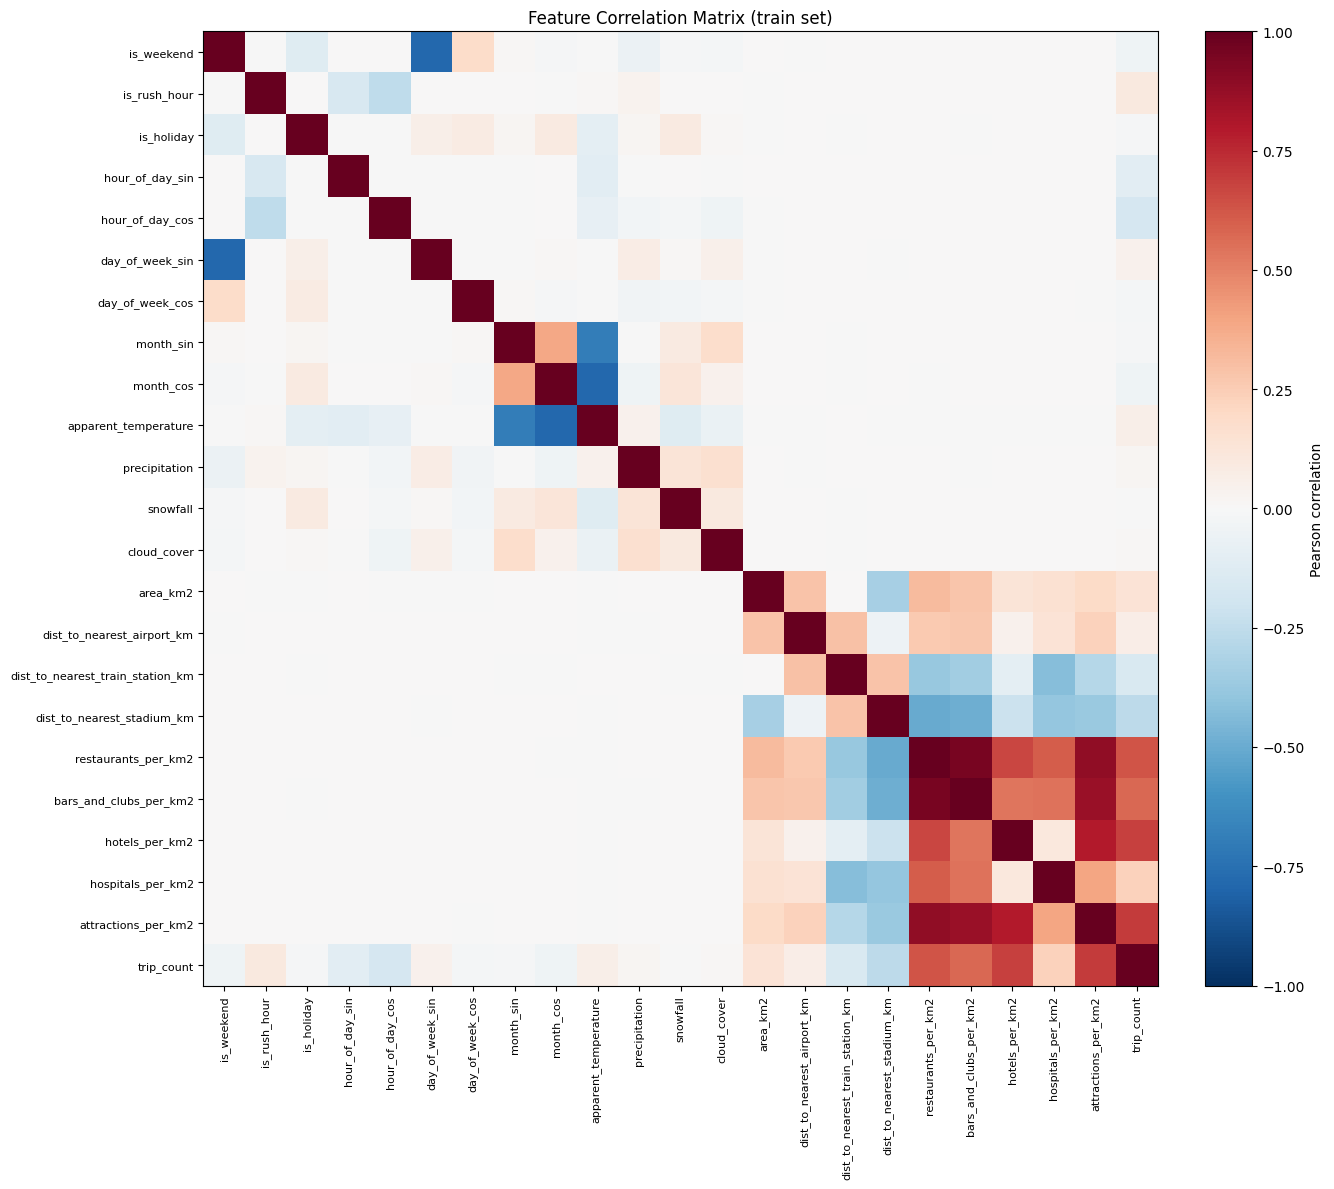

Feature pairs with |correlation| >= 0.8:
  restaurants_per_km2                 vs bars_and_clubs_per_km2               r=+0.952
  restaurants_per_km2                 vs attractions_per_km2                  r=+0.888
  bars_and_clubs_per_km2              vs attractions_per_km2                  r=+0.863


In [158]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Correlation Matrix                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

corr_cols   = FEATURE_COLS + [TARGET_COL]
corr_matrix = train_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90, fontsize=8)
ax.set_yticklabels(corr_cols, fontsize=8)

fig.colorbar(im, ax=ax, label="Pearson correlation", fraction=0.046, pad=0.04)
ax.set_title("Feature Correlation Matrix (train set)")
plt.tight_layout()
plt.show()

# Highly correlated feature pairs -> candidates for removal
THRESHOLD = 0.8
pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        c = corr_matrix.iloc[i, j]
        if abs(c) >= THRESHOLD:
            pairs.append((corr_cols[i], corr_cols[j], c))
pairs.sort(key=lambda x: -abs(x[2]))

print(f"Feature pairs with |correlation| >= {THRESHOLD}:")
if pairs:
    for a, b, c in pairs:
        print(f"  {a:<35s} vs {b:<35s}  r={c:+.3f}")
else:
    print("  none")

In [159]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model-Based Feature Importance          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=0, n_jobs=-1)
rf.fit(train_data[FEATURE_COLS], train_data[TARGET_COL])

perm = permutation_importance(
    rf, train_data[FEATURE_COLS], train_data[TARGET_COL],
    n_repeats=10, random_state=0, n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature":             FEATURE_COLS,
    "rf_importance":       rf.feature_importances_,
    "perm_importance":     perm.importances_mean,
    "perm_importance_std": perm.importances_std,
}).sort_values("perm_importance", ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))

# Features that don't measurably help (or hurt) the model when shuffled
LOW_IMPORTANCE = importance_df.loc[importance_df["perm_importance"] <= 0, "feature"].tolist()
print(f"\nFeatures with permutation importance <= 0 (no measurable contribution, or hurting the model):")
print(f"  {LOW_IMPORTANCE if LOW_IMPORTANCE else 'none'}")

                         feature  rf_importance  perm_importance  perm_importance_std
                 hour_of_day_cos       0.200459         0.474581             0.004704
                 hour_of_day_sin       0.114061         0.239469             0.004589
             attractions_per_km2       0.187357         0.235216             0.001639
             restaurants_per_km2       0.171551         0.179105             0.001430
                  hotels_per_km2       0.164777         0.138667             0.001338
      dist_to_nearest_airport_km       0.023998         0.062556             0.000233
                 day_of_week_sin       0.029074         0.051390             0.000808
          bars_and_clubs_per_km2       0.037488         0.037512             0.000183
                       month_cos       0.014855         0.027579             0.000773
                      is_weekend       0.018366         0.021609             0.000501
                 day_of_week_cos       0.005652       

## 4.2.8 Benchmark Models

Before diving into the three NN architectures, we evaluate two simple non-neural baselines on the held-out test set:

1. **Historical-mean predictor** — for each hexagon × hour-of-day pair, predict the mean `trip_count` observed in the training split. Unseen combinations fall back to the global training mean.
2. **Ridge regression** — a linear model on the same scaled feature matrix (`X_train`). Trained on log₁⁺ demand and back-transformed with `expm1` at evaluation time, matching the NN target encoding.

These numbers set the floor: any NN that cannot beat Ridge is not adding value.

Metrics match the NN evaluation cells:
- **R²** — coefficient of determination
- **MAE** — mean absolute error (in raw trip counts)
- **RMSE** — root mean squared error
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [160]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Benchmark Models                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

print(f"Zero-demand rows : {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}\n")


def _eval_benchmark(label, preds):
    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot
    print(f"{label:<35s}  R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  NRMSE={nrmse:.4f}")
    return dict(r2=round(r2, 6), mae=round(mae, 6), rmse=round(rmse, 6), nrmse=round(nrmse, 6))


# ── 1. Historical-mean predictor ───────────────────────────────────────────────
mean_table = (
    train_data.groupby(['pickup_h3_res6', 'hour_of_day'])['trip_count']
    .mean()
    .rename('pred_mean')
)
global_mean = float(train_data['trip_count'].mean())

test_lookup      = test_data[['pickup_h3_res6', 'hour_of_day']].copy()
test_lookup      = test_lookup.join(mean_table, on=['pickup_h3_res6', 'hour_of_day'])
hist_mean_preds  = test_lookup['pred_mean'].fillna(global_mean).values

bm_hist = _eval_benchmark("Historical mean (hex × hour)", hist_mean_preds)

# ── 2. Ridge regression ────────────────────────────────────────────────────────
ridge        = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)            # y_train is raw counts (Poisson) or log1p-transformed
ridge_preds  = ridge.predict(X_test) if IS_POISSON else np.expm1(ridge.predict(X_test))
ridge_preds  = np.maximum(ridge_preds, 0.0)   # clamp to non-negative

bm_ridge = _eval_benchmark("Ridge regression", ridge_preds)


Zero-demand rows : 15,505 / 43,362 (35.8%)
Mean actual test demand : 17.5691

Historical mean (hex × hour)         R²=0.8329  MAE=7.2371  RMSE=22.9434  NRMSE=1.3059
Ridge regression                     R²=0.5927  MAE=13.2325  RMSE=35.8214  NRMSE=2.0389


## Embed Dimension Search

Since `embed_dim` is independent of architecture depth and width, we search it once on
the baseline and fix the winner globally for all three models.

Candidates: `[8, 16, 32]` — 3 runs total (1 seed, early stopping).


In [161]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Embed Dimension Search                  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

EMBED_CANDIDATES = [8, 16, 32]

print(f"Embed search — ARCH_BASELINE, seed=0, patience={HP_PATIENCE}\n")
embed_results = []
for emb in EMBED_CANDIDATES:
    _, val_loss, _ = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=0, device=device, verbose=False,
        lr=config.LEARNING_RATE, embed_dim=emb, patience=HP_PATIENCE,
    )
    embed_results.append((emb, val_loss))
    print(f"  embed_dim={emb:>3}  val_loss={val_loss:.4f}")

best_embed_dim = min(embed_results, key=lambda x: x[1])[0]
HEX_EMBED_DIM        = best_embed_dim
config.HEX_EMBED_DIM = best_embed_dim
print(f"\nBest embed_dim: {HEX_EMBED_DIM}  →  set as global HEX_EMBED_DIM")


Embed search — ARCH_BASELINE, seed=0, patience=10

  embed_dim=  8  val_loss=2.1603
  embed_dim= 16  val_loss=2.1500
  embed_dim= 32  val_loss=2.1551

Best embed_dim: 16  →  set as global HEX_EMBED_DIM


## 4.2.9 Baseline Model — Training

Run `ARCH_BASELINE = (2 hidden layers, 64 units)` across all seeds and report
the mean ± std validation loss.


In [162]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Visualization          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

input_dim = X_train.shape[1]
n_layers, width = ARCH_BASELINE

viz_model = DemandBaseline(input_dim, n_layers, width, N_HEX, HEX_EMBED_DIM)
x_dummy   = torch.zeros(1, input_dim)
h_dummy   = torch.zeros(1, dtype=torch.long)
summary(viz_model, input_data=(x_dummy, h_dummy), col_names=["input_size", "output_size", "num_params"], verbose=1)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 22]                   [1]                       1
├─Embedding: 1-1                         [1]                       [1, 16]                   544
├─Sequential: 1-2                        [1, 38]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 38]                   [1, 64]                   2,496
│    └─Sigmoid: 2-2                      [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─Sigmoid: 2-4                      [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
Total params: 7,266
Trainable params: 7,266
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 22]                   [1]                       1
├─Embedding: 1-1                         [1]                       [1, 16]                   544
├─Sequential: 1-2                        [1, 38]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 38]                   [1, 64]                   2,496
│    └─Sigmoid: 2-2                      [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─Sigmoid: 2-4                      [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
Total params: 7,266
Trainable params: 7,266
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 

In [163]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Training               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

print(f"Device: {device}\n")

baseline_train_losses = []
baseline_val_losses   = []
baseline_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
    )
    baseline_train_losses.append(train_loss)
    baseline_val_losses.append(val_loss)
    baseline_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(baseline_train_losses):.4f} \u00b1 {np.std(baseline_train_losses):.4f}  val: {np.mean(baseline_val_losses):.4f} \u00b1 {np.std(baseline_val_losses):.4f}")

Device: cpu

Epoch   1/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 7.2620  val_loss: 6.1749 ✓
Epoch   2/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 4.9045  val_loss: 4.6918 ✓
Epoch   3/200


...

  loss: 2.1030  val_loss: 2.1556  (no improvement 5/10)
Epoch 199/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 2.1021  val_loss: 2.1561  (no improvement 6/10)
Epoch 200/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 2.1009  val_loss: 2.1500 ✓

baseline  train: 2.1009 ± 0.0000  val: 2.1500 ± 0.0000


### 4.2.9 Baseline Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [164]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)
hex_test_t = torch.as_tensor(hex_test, dtype=torch.long).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_BASELINE

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, baseline_models):
    model.eval()

    print(f"  seed={seed} layer weight stats:")
    for name, param in model.named_parameters():
        if "weight" in name:
            w = param.detach().cpu().numpy()
            print(f"    {name:<14s}  shape={str(tuple(w.shape)):<12}"
                  f"  max|w|={np.abs(w).max():.4f}  mean|w|={np.abs(w).mean():.4f}  norm={np.linalg.norm(w):.4f}")

    with torch.no_grad():
        preds_raw = model(X_test_t, hex_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R\u00b2={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R\u00b2={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "training_loss"     : config.LOSS,
        "model"             : ARCH_NAMES.get((n_layers, width), "unknown"),
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : config.LEARNING_RATE,
        "weight_decay"      : getattr(config, "WEIGHT_DECAY", 0.0),
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "hidden_activation" : getattr(config, "HIDDEN_ACTIVATION", "relu"),
        "val_loss"          : baseline_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : round(mean_actual, 6),
        "r2"                : round(r2,       6),
        "mae"               : round(mae,      6),
        "rmse"              : round(rmse,     6),
        "nrmse"             : round(nrmse,    6),
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

arch_label = ARCH_NAMES.get((n_layers, width), "model")
print(f"\n--- original scale ---")
print(f"{arch_label.capitalize()}  R\u00b2    : {np.mean(r2_scores):.4f} \u00b1 {np.std(r2_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_scores):.4f} \u00b1 {np.std(mae_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_scores):.4f} \u00b1 {np.std(rmse_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_scores):.4f} \u00b1 {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"{arch_label.capitalize()}  R\u00b2    : {np.mean(r2_log_scores):.4f} \u00b1 {np.std(r2_log_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_log_scores):.4f} \u00b1 {np.std(mae_log_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_log_scores):.4f} \u00b1 {np.std(rmse_log_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_log_scores):.4f} \u00b1 {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"{arch_label.capitalize()}  Correct-zero : {np.mean(correct_zero_counts):.1f} \u00b1 {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"{arch_label.capitalize()}  False-zero   : {np.mean(false_zero_counts):.1f} \u00b1 {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, baseline_train_losses, baseline_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(baseline_train_losses):>8.4f}  {np.mean(baseline_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 15,505 / 43,362 (35.8%)
Mean actual test demand : 17.5691  (min=0.0000, max=746.0000)

  seed=0 layer weight stats:
    hex_embed.weight  shape=(34, 16)      max|w|=1.3458  mean|w|=0.1408  norm=6.5743
    net.0.weight    shape=(64, 38)      max|w|=1.4443  mean|w|=0.1787  norm=12.0152
    net.2.weight    shape=(64, 64)      max|w|=1.1296  mean|w|=0.1577  norm=12.9348
    net.4.weight    shape=(1, 64)       max|w|=0.8030  mean|w|=0.3286  norm=2.8228
  seed=0  R²=0.7762  MAE=7.3650  NRMSE=1.5112  | log  R²=0.8785  MAE=0.3851  NRMSE=0.3792  | zeros 10,376/15,505  false=1,213  | pred min=0.0 max=431.5

--- original scale ---
Baseline  R²    : 0.7762 ± 0.0000
Baseline  MAE   : 7.3650 ± 0.0000
Baseline  RMSE  : 26.5507 ± 0.0000
Baseline  NRMSE : 1.5112 ± 0.0000

--- log1p scale ---
Baseline  R²    : 0.8785 ± 0.0000
Baseline  MAE   : 0.3851 ± 0.0000
Baseline  RMSE  : 0.5231 ± 0.0000
Baseline  NRMSE : 0.3792 ± 0.0000

--- zero-demand ---
Baseline  Correct-zero : 10376.0 ± 0.0 

In [165]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_hex_6_1h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))


Appended 1 rows to data/results/nn_results_hex_6_1h.csv (26 columns)
          timestamp training_loss    model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae    rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min  pred_max  overfitting_measures hidden_activation
2026-07-13T17:58:12        nb_nll baseline         2     64        0.00005           0.0        1024     0  2.150032              15505    17.569093 0.776237 7.365044 26.5507 1.511216 0.878522 0.385147  0.523126   0.379161         10376        1213  0.001298 431.46106                   NaN           sigmoid


## 4.2.10 Hyperparameter Search — Baseline Model

Grid search over 4 hyperparameters using the best LR from the LR search above.

| Hyperparameter | Candidates |
|---|---|
| `lr`           | 2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 1e-4 |

Full grid: 4 × 4 × 3 = **48 combinations** × 1 seed = **48 training runs**.  
The best combination is stored in `BEST_HP[ARCH_BASELINE]`.


In [166]:
# HP search candidates — Baseline (2 layers × 64 units)
# Starting grid transferred from CA 1h (best there: lr = 9e-3);
# re-centre the grid if the best value sits at an edge
# LR_CANDIDATES_BASELINE = [3e-3, 4e-3, 5e-3, 6e-3, 7e-3, 8e-3, 9e-3, 1e-2, 2e-2] # best LR=0.02
LR_CANDIDATES_BASELINE = [4e-2, 5e-2, 6e-2, 7e-2, 8e-2] # best LR=0.02

# Weight decay grid (0 = unregularized control). To keep the lr × wd grid
# small, pin LR_CANDIDATES_BASELINE to its best value first.
WD_CANDIDATES_BASELINE = [2e-3, 5e-3, 6e-3, 7e-3, 8e-3]


In [167]:
run_hp_search(
    ARCH_BASELINE,
    X_train, y_train, X_val, y_val,
    hex_train, hex_val,
    device=device,
    lr_candidates=LR_CANDIDATES_BASELINE,
    wd_candidates=WD_CANDIDATES_BASELINE,
)

HP Search — baseline
25 combos × 1 seed(s) = 25 runs  |  patience=10

   #        lr        wd    mean val       std
---------------------------------------------
   1     4e-02     2e-03      2.0750    0.0000
   2     4e-02     5e-03      2.0588    0.0000
   3     4e-02     6e-03      2.0938    0.0000
   4     4e-02     7e-03      2.0685    0.0000
   5     4e-02     8e-03      2.0682    0.0000
   6     5e-02     2e-03      2.0758    0.0000
   7     5e-02     5e-03      2.0833    0.0000
   8     5e-02     6e-03      2.0742    0.0000
   9     5e-02     7e-03      2.0725    0.0000
  10     5e-02     8e-03      2.0910    0.0000
  11     6e-02     2e-03      2.0846    0.0000
  12     6e-02     5e-03      2.0647    0.0000
  13     6e-02     6e-03      2.0812    0.0000
  14     6e-02     7e-03      2.0775    0.0000
  15     6e-02     8e-03      2.0842    0.0000
  16     7e-02     2e-03      2.1081    0.0000
  17     7e-02     5e-03      2.0932    0.0000
  18     7e-02     6e-03      2.0800  

{'lr': 0.04, 'weight_decay': 0.005}

### 4.2.10 Tuned Baseline — Training

Re-train the baseline architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.


In [168]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_BASELINE]
print(f"Best HP: {hp}\n")

tuned_train_losses = []
tuned_val_losses   = []
tuned_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
    )
    tuned_train_losses.append(train_loss)
    tuned_val_losses.append(val_loss)
    tuned_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(tuned_train_losses):.4f} \u00b1 {np.std(tuned_train_losses):.4f}  val: {np.mean(tuned_val_losses):.4f} \u00b1 {np.std(tuned_val_losses):.4f}")

Best HP: {'lr': 0.04, 'weight_decay': 0.005}

Epoch   1/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 2.7299  val_loss: 2.2561 ✓
Epoch   2/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 2.1331  val_loss: 2.1694 ✓
Epoch   3/200


...

  loss: 1.9860  val_loss: 2.1452  (no improvement 8/10)
Epoch  29/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 1.9852  val_loss: 2.2226  (no improvement 9/10)
Epoch  30/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 1.9871  val_loss: 2.1340  (no improvement 10/10)

  ↳ early stop at epoch 30  best_val=2.0588  best_train=1.9905

baseline  train: 1.9905 ± 0.0000  val: 2.0588 ± 0.0000


### 4.2.10 Tuned Baseline — Evaluation

Evaluate on the held-out **test set** and compare against the untuned baseline.


In [169]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)
hex_test_t = torch.as_tensor(hex_test, dtype=torch.long).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_BASELINE

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, tuned_models):
    model.eval()

    with torch.no_grad():
        preds_raw = model(X_test_t, hex_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R\u00b2={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R\u00b2={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "training_loss"     : config.LOSS,
        "model"             : "baseline_tuned",
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : BEST_HP[ARCH_BASELINE]["lr"],
        "weight_decay"      : BEST_HP[ARCH_BASELINE].get("weight_decay", 0.0),
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "hidden_activation" : getattr(config, "HIDDEN_ACTIVATION", "relu"),
        "val_loss"          : tuned_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : mean_actual,
        "r2"                : r2,
        "mae"               : mae,
        "rmse"              : rmse,
        "nrmse"             : nrmse,
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

print(f"\n--- original scale ---")
print(f"Tuned Baseline  R\u00b2    : {np.mean(r2_scores):.4f} \u00b1 {np.std(r2_scores):.4f}")
print(f"Tuned Baseline  MAE   : {np.mean(mae_scores):.4f} \u00b1 {np.std(mae_scores):.4f}")
print(f"Tuned Baseline  RMSE  : {np.mean(rmse_scores):.4f} \u00b1 {np.std(rmse_scores):.4f}")
print(f"Tuned Baseline  NRMSE : {np.mean(nrmse_scores):.4f} \u00b1 {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"Tuned Baseline  R\u00b2    : {np.mean(r2_log_scores):.4f} \u00b1 {np.std(r2_log_scores):.4f}")
print(f"Tuned Baseline  MAE   : {np.mean(mae_log_scores):.4f} \u00b1 {np.std(mae_log_scores):.4f}")
print(f"Tuned Baseline  RMSE  : {np.mean(rmse_log_scores):.4f} \u00b1 {np.std(rmse_log_scores):.4f}")
print(f"Tuned Baseline  NRMSE : {np.mean(nrmse_log_scores):.4f} \u00b1 {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"Tuned Baseline  Correct-zero : {np.mean(correct_zero_counts):.1f} \u00b1 {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"Tuned Baseline  False-zero   : {np.mean(false_zero_counts):.1f} \u00b1 {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, tuned_train_losses, tuned_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(tuned_train_losses):>8.4f}  {np.mean(tuned_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 15,505 / 43,362 (35.8%)
Mean actual test demand : 17.5691  (min=0.0000, max=746.0000)

  seed=0  R²=0.8336  MAE=6.6179  NRMSE=1.3031  | log  R²=0.8832  MAE=0.3779  NRMSE=0.3718  | zeros 10,080/15,505  false=1,090  | pred min=0.0 max=603.2

--- original scale ---
Tuned Baseline  R²    : 0.8336 ± 0.0000
Tuned Baseline  MAE   : 6.6179 ± 0.0000
Tuned Baseline  RMSE  : 22.8951 ± 0.0000
Tuned Baseline  NRMSE : 1.3031 ± 0.0000

--- log1p scale ---
Tuned Baseline  R²    : 0.8832 ± 0.0000
Tuned Baseline  MAE   : 0.3779 ± 0.0000
Tuned Baseline  RMSE  : 0.5130 ± 0.0000
Tuned Baseline  NRMSE : 0.3718 ± 0.0000

--- zero-demand ---
Tuned Baseline  Correct-zero : 10080.0 ± 0.0  (out of 15,505)
Tuned Baseline  False-zero   : 1090.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Baseline  Pred min : 0.0021 ± 0.0000
Baseline  Pred max : 603.1572 ± 0.0000  (actual max: 746.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val     

In [170]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_hex_6_1h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))


Appended 1 rows to data/results/nn_results_hex_6_1h.csv (26 columns)
          timestamp training_loss          model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min   pred_max  overfitting_measures hidden_activation
2026-07-13T18:51:06        nb_nll baseline_tuned         2     64           0.04         0.005        1024     0  2.058837              15505    17.569093 0.833612 6.617881 22.895087 1.303146 0.883192 0.377932  0.512972   0.371802         10080        1090  0.002052 603.157166                   NaN           sigmoid


## 4.2.11 Deeper Model — Training

Run `ARCH_DEEPER = (4 hidden layers, 64 units)` across all seeds.
Width is fixed; depth doubles relative to the baseline.


In [171]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

deeper_train_losses = []
deeper_val_losses   = []
deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
    )
    deeper_train_losses.append(train_loss)
    deeper_val_losses.append(val_loss)
    deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(deeper_train_losses):.4f} \u00b1 {np.std(deeper_train_losses):.4f}  val: {np.mean(deeper_val_losses):.4f} \u00b1 {np.std(deeper_val_losses):.4f}")

Epoch   1/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 9.8915  val_loss: 8.0199 ✓
Epoch   2/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 5.9663  val_loss: 5.4601 ✓
Epoch   3/200


...

  loss: 2.1149  val_loss: 2.1334 ✓
Epoch 199/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 2.1135  val_loss: 2.1428  (no improvement 1/10)
Epoch 200/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 2.1128  val_loss: 2.1393  (no improvement 2/10)

deep  train: 2.1149 ± 0.0000  val: 2.1334 ± 0.0000


### 4.2.11 Deeper Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [172]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)
hex_test_t = torch.as_tensor(hex_test, dtype=torch.long).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_DEEPER

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, deeper_models):
    model.eval()

    with torch.no_grad():
        preds_raw = model(X_test_t, hex_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R²={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R²={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "training_loss"     : config.LOSS,
        "model"             : ARCH_NAMES.get((n_layers, width), "unknown"),
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : config.LEARNING_RATE,
        "weight_decay"      : getattr(config, "WEIGHT_DECAY", 0.0),
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "hidden_activation" : getattr(config, "HIDDEN_ACTIVATION", "relu"),
        "val_loss"          : deeper_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : round(mean_actual, 6),
        "r2"                : round(r2,       6),
        "mae"               : round(mae,      6),
        "rmse"              : round(rmse,     6),
        "nrmse"             : round(nrmse,    6),
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

arch_label = ARCH_NAMES.get((n_layers, width), "model")
print(f"\n--- original scale ---")
print(f"{arch_label.capitalize()}  R²    : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_scores):.4f} ± {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"{arch_label.capitalize()}  R²    : {np.mean(r2_log_scores):.4f} ± {np.std(r2_log_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_log_scores):.4f} ± {np.std(mae_log_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_log_scores):.4f} ± {np.std(rmse_log_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_log_scores):.4f} ± {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"{arch_label.capitalize()}  Correct-zero : {np.mean(correct_zero_counts):.1f} ± {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"{arch_label.capitalize()}  False-zero   : {np.mean(false_zero_counts):.1f} ± {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, deeper_train_losses, deeper_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(deeper_train_losses):>8.4f}  {np.mean(deeper_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 15,505 / 43,362 (35.8%)
Mean actual test demand : 17.5691  (min=0.0000, max=746.0000)

  seed=0  R²=0.8006  MAE=7.0638  NRMSE=1.4265  | log  R²=0.8791  MAE=0.3839  NRMSE=0.3783  | zeros 10,434/15,505  false=1,253  | pred min=0.0 max=421.0

--- original scale ---
Deep  R²    : 0.8006 ± 0.0000
Deep  MAE   : 7.0638 ± 0.0000
Deep  RMSE  : 25.0623 ± 0.0000
Deep  NRMSE : 1.4265 ± 0.0000

--- log1p scale ---
Deep  R²    : 0.8791 ± 0.0000
Deep  MAE   : 0.3839 ± 0.0000
Deep  RMSE  : 0.5219 ± 0.0000
Deep  NRMSE : 0.3783 ± 0.0000

--- zero-demand ---
Deep  Correct-zero : 10434.0 ± 0.0  (out of 15,505)
Deep  False-zero   : 1253.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Deep  Pred min : 0.0060 ± 0.0000
Deep  Pred max : 421.0220 ± 0.0000  (actual max: 746.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       2.1149    2.1334    0.2724


In [173]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_hex_6_1h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))


Appended 1 rows to data/results/nn_results_hex_6_1h.csv (26 columns)
          timestamp training_loss model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min   pred_max  overfitting_measures hidden_activation
2026-07-13T18:54:21        nb_nll  deep         8     64        0.00005           0.0        1024     0  2.133412              15505    17.569093 0.800622 7.063773 25.062289 1.426499 0.879095 0.383922  0.521891   0.378266         10434        1253  0.005977 421.021973                   NaN           sigmoid


## 4.2.12 Hyperparameter Search — Deeper Model

Same grid search as for the baseline, run on `ARCH_DEEPER = (4 hidden layers, 64 units)`.
Result is stored in `BEST_HP[ARCH_DEEPER]`.

| Hyperparameter | Candidates |
|---|---|
| `lr`           | 2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 1e-4 |

Full grid: 4 × 4 × 3 = **48 combinations** × 1 seed = **48 training runs**.  
The best combination is stored in `BEST_HP[ARCH_DEEPER]`.

In [174]:
# HP search candidates — Deeper (8 layers × 64 units)
# Starting grid transferred from CA 1h (best there: lr = 4e-3);
# re-centre the grid if the best value sits at an edge
LR_CANDIDATES_DEEPER   = [3e-3, 4e-3, 5e-3, 6e-3, 7e-3, 8e-3, 9e-3]

# Weight decay grid (0 = unregularized control). To keep the lr × wd grid
# small, pin LR_CANDIDATES_DEEPER to its best value first.
WD_CANDIDATES_DEEPER = [0.0, 9e-4, 1e-5, 1e-4, 1e-3, 3e-3, 7e-3]


In [175]:
run_hp_search(
    ARCH_DEEPER,
    X_train, y_train, X_val, y_val,
    hex_train, hex_val,
    device=device,
    lr_candidates=LR_CANDIDATES_DEEPER,
    wd_candidates=WD_CANDIDATES_DEEPER,
)

HP Search — deep
49 combos × 1 seed(s) = 49 runs  |  patience=10

   #        lr        wd    mean val       std
---------------------------------------------
   1     3e-03     0e+00      2.0538    0.0000
   2     3e-03     9e-04      2.0538    0.0000
   3     3e-03     1e-05      2.0569    0.0000
   4     3e-03     1e-04      2.0583    0.0000
   5     3e-03     1e-03      2.0662    0.0000
   6     3e-03     3e-03      2.0669    0.0000
   7     3e-03     7e-03      2.0625    0.0000
   8     4e-03     0e+00      2.0542    0.0000
   9     4e-03     9e-04      2.0547    0.0000
  10     4e-03     1e-05      2.0544    0.0000
  11     4e-03     1e-04      2.0526    0.0000
  12     4e-03     1e-03      2.0507    0.0000
  13     4e-03     3e-03      2.0480    0.0000
  14     4e-03     7e-03      2.0530    0.0000
  15     5e-03     0e+00      2.0622    0.0000
  16     5e-03     9e-04      2.0569    0.0000
  17     5e-03     1e-05      2.0515    0.0000
  18     5e-03     1e-04      2.0533    0.

{'lr': 0.006, 'weight_decay': 0.003}

### 4.2.12 Tuned Deeper — Training

Re-train the deeper architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.

In [176]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Training                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_DEEPER]
print(f"Best HP: {hp}\n")

tuned_deeper_train_losses = []
tuned_deeper_val_losses   = []
tuned_deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
    )
    tuned_deeper_train_losses.append(train_loss)
    tuned_deeper_val_losses.append(val_loss)
    tuned_deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(tuned_deeper_train_losses):.4f} ± {np.std(tuned_deeper_train_losses):.4f}  val: {np.mean(tuned_deeper_val_losses):.4f} ± {np.std(tuned_deeper_val_losses):.4f}")

Best HP: {'lr': 0.006, 'weight_decay': 0.003}

Epoch   1/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 3.7590  val_loss: 3.4587 ✓
Epoch   2/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 3.1293  val_loss: 2.7708 ✓
Epoch   3/200


...

  loss: 1.9801  val_loss: 2.0729  (no improvement 8/10)
Epoch  23/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 1.9794  val_loss: 2.0692  (no improvement 9/10)
Epoch  24/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 1.9770  val_loss: 2.0729  (no improvement 10/10)

  ↳ early stop at epoch 24  best_val=2.0445  best_train=2.0012

deep  train: 2.0012 ± 0.0000  val: 2.0445 ± 0.0000


### 4.2.12 Tuned Deeper — Evaluation

Evaluate on the held-out **test set** and compare against the untuned deeper model.

In [177]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Evaluation               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import datetime

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)
hex_test_t = torch.as_tensor(hex_test, dtype=torch.long).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_DEEPER

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, tuned_deeper_models):
    model.eval()

    with torch.no_grad():
        preds_raw = model(X_test_t, hex_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R²={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R²={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "training_loss"     : config.LOSS,
        "model"             : "deep_tuned",
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : BEST_HP[ARCH_DEEPER]["lr"],
        "weight_decay"      : BEST_HP[ARCH_DEEPER].get("weight_decay", 0.0),
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "hidden_activation" : getattr(config, "HIDDEN_ACTIVATION", "relu"),
        "val_loss"          : tuned_deeper_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : round(mean_actual, 6),
        "r2"                : round(r2,       6),
        "mae"               : round(mae,      6),
        "rmse"              : round(rmse,     6),
        "nrmse"             : round(nrmse,    6),
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

print(f"\n--- original scale ---")
print(f"Tuned Deeper  R²    : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"Tuned Deeper  MAE   : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"Tuned Deeper  RMSE  : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"Tuned Deeper  NRMSE : {np.mean(nrmse_scores):.4f} ± {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"Tuned Deeper  R²    : {np.mean(r2_log_scores):.4f} ± {np.std(r2_log_scores):.4f}")
print(f"Tuned Deeper  MAE   : {np.mean(mae_log_scores):.4f} ± {np.std(mae_log_scores):.4f}")
print(f"Tuned Deeper  RMSE  : {np.mean(rmse_log_scores):.4f} ± {np.std(rmse_log_scores):.4f}")
print(f"Tuned Deeper  NRMSE : {np.mean(nrmse_log_scores):.4f} ± {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"Tuned Deeper  Correct-zero : {np.mean(correct_zero_counts):.1f} ± {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"Tuned Deeper  False-zero   : {np.mean(false_zero_counts):.1f} ± {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, tuned_deeper_train_losses, tuned_deeper_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(tuned_deeper_train_losses):>8.4f}  {np.mean(tuned_deeper_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 15,505 / 43,362 (35.8%)
Mean actual test demand : 17.5691  (min=0.0000, max=746.0000)

  seed=0  R²=0.8492  MAE=6.4002  NRMSE=1.2404  | log  R²=0.8823  MAE=0.3754  NRMSE=0.3731  | zeros 10,798/15,505  false=1,352  | pred min=0.0 max=495.1

--- original scale ---
Tuned Deeper  R²    : 0.8492 ± 0.0000
Tuned Deeper  MAE   : 6.4002 ± 0.0000
Tuned Deeper  RMSE  : 21.7933 ± 0.0000
Tuned Deeper  NRMSE : 1.2404 ± 0.0000

--- log1p scale ---
Tuned Deeper  R²    : 0.8823 ± 0.0000
Tuned Deeper  MAE   : 0.3754 ± 0.0000
Tuned Deeper  RMSE  : 0.5148 ± 0.0000
Tuned Deeper  NRMSE : 0.3731 ± 0.0000

--- zero-demand ---
Tuned Deeper  Correct-zero : 10798.0 ± 0.0  (out of 15,505)
Tuned Deeper  False-zero   : 1352.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Deep  Pred min : 0.0157 ± 0.0000
Deep  Pred max : 495.1049 ± 0.0000  (actual max: 746.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       2.0012 

In [178]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_hex_6_1h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))

Appended 1 rows to data/results/nn_results_hex_6_1h.csv (26 columns)
          timestamp training_loss      model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae     rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min   pred_max  overfitting_measures hidden_activation
2026-07-13T19:12:16        nb_nll deep_tuned         8     64          0.006         0.003        1024     0  2.044485              15505    17.569093 0.849242 6.400195 21.79327 1.240432 0.882347  0.37542  0.514824   0.373144         10798        1352  0.015671 495.104889                   NaN           sigmoid


### 4.2.12 Wider Model — Training

Run `ARCH_WIDER = (2 hidden layers, 128 units)` across all seeds.
Depth is fixed; width doubles relative to the baseline.


In [179]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

wider_train_losses = []
wider_val_losses   = []
wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
    )
    wider_train_losses.append(train_loss)
    wider_val_losses.append(val_loss)
    wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(wider_train_losses):.4f} \u00b1 {np.std(wider_train_losses):.4f}  val: {np.mean(wider_val_losses):.4f} \u00b1 {np.std(wider_val_losses):.4f}")

Epoch   1/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 8.3433  val_loss: 4.3339 ✓
Epoch   2/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 3.8887  val_loss: 3.9259 ✓
Epoch   3/200


...

  loss: 2.0828  val_loss: 2.1227  (no improvement 1/10)
Epoch 199/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 2.0821  val_loss: 2.1243  (no improvement 2/10)
Epoch 200/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 2.0812  val_loss: 2.1230  (no improvement 3/10)

wide  train: 2.0839 ± 0.0000  val: 2.1152 ± 0.0000


### 4.2.12 Wider Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)

In [180]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import datetime

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)
hex_test_t = torch.as_tensor(hex_test, dtype=torch.long).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_WIDER

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, wider_models):
    model.eval()

    with torch.no_grad():
        preds_raw = model(X_test_t, hex_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R²={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R²={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "training_loss"     : config.LOSS,
        "model"             : ARCH_NAMES.get((n_layers, width), "unknown"),
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : config.LEARNING_RATE,
        "weight_decay"      : getattr(config, "WEIGHT_DECAY", 0.0),
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "hidden_activation" : getattr(config, "HIDDEN_ACTIVATION", "relu"),
        "val_loss"          : wider_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : round(mean_actual, 6),
        "r2"                : round(r2,       6),
        "mae"               : round(mae,      6),
        "rmse"              : round(rmse,     6),
        "nrmse"             : round(nrmse,    6),
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

arch_label = ARCH_NAMES.get((n_layers, width), "model")
print(f"\n--- original scale ---")
print(f"{arch_label.capitalize()}  R²    : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_scores):.4f} ± {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"{arch_label.capitalize()}  R²    : {np.mean(r2_log_scores):.4f} ± {np.std(r2_log_scores):.4f}")
print(f"{arch_label.capitalize()}  MAE   : {np.mean(mae_log_scores):.4f} ± {np.std(mae_log_scores):.4f}")
print(f"{arch_label.capitalize()}  RMSE  : {np.mean(rmse_log_scores):.4f} ± {np.std(rmse_log_scores):.4f}")
print(f"{arch_label.capitalize()}  NRMSE : {np.mean(nrmse_log_scores):.4f} ± {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"{arch_label.capitalize()}  Correct-zero : {np.mean(correct_zero_counts):.1f} ± {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"{arch_label.capitalize()}  False-zero   : {np.mean(false_zero_counts):.1f} ± {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, wider_train_losses, wider_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(wider_train_losses):>8.4f}  {np.mean(wider_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 15,505 / 43,362 (35.8%)
Mean actual test demand : 17.5691  (min=0.0000, max=746.0000)

  seed=0  R²=0.7792  MAE=7.2829  NRMSE=1.5012  | log  R²=0.8831  MAE=0.3782  NRMSE=0.3720  | zeros 10,234/15,505  false=1,067  | pred min=0.0 max=416.6

--- original scale ---
Wide  R²    : 0.7792 ± 0.0000
Wide  MAE   : 7.2829 ± 0.0000
Wide  RMSE  : 26.3752 ± 0.0000
Wide  NRMSE : 1.5012 ± 0.0000

--- log1p scale ---
Wide  R²    : 0.8831 ± 0.0000
Wide  MAE   : 0.3782 ± 0.0000
Wide  RMSE  : 0.5133 ± 0.0000
Wide  NRMSE : 0.3720 ± 0.0000

--- zero-demand ---
Wide  Correct-zero : 10234.0 ± 0.0  (out of 15,505)
Wide  False-zero   : 1067.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Wide  Pred min : 0.0003 ± 0.0000
Wide  Pred max : 416.5865 ± 0.0000  (actual max: 746.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       2.0839    2.1152    0.2635


In [181]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_hex_6_1h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))


Appended 1 rows to data/results/nn_results_hex_6_1h.csv (26 columns)
          timestamp training_loss model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2     mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min   pred_max  overfitting_measures hidden_activation
2026-07-13T19:14:37        nb_nll  wide         2    256        0.00005           0.0        1024     0  2.115175              15505    17.569093 0.779185 7.28293 26.375222 1.501228 0.883054  0.37824  0.513276   0.372022         10234        1067  0.000289 416.586456                   NaN           sigmoid


### 4.2.12 Hyperparameter Search — Wider Model

Same grid search as for the baseline, run on `ARCH_WIDER = (2 hidden layers, 128 units)`.
Result is stored in `BEST_HP[ARCH_WIDER]`.

| Hyperparameter | Candidates |
|---|---|
| `lr`           | 2e-5, 3e-5, 4e-5, 5e-5, 6e-5, 7e-5, 1e-4 |

Full grid: 4 × 4 × 3 = **48 combinations** × 1 seed = **48 training runs**.  
The best combination is stored in `BEST_HP[ARCH_WIDER]`.

In [182]:
# HP search candidates — Wider (2 layers × 256 units)
# Starting grid transferred from CA 1h (best there: lr = 5e-3);
# re-centre the grid if the best value sits at an edge
# LR_CANDIDATES_WIDER = [9e-4, 1e-3, 2e-3, 3e-3, 4e-3, 5e-3, 7e-3]
LR_CANDIDATES_WIDER = [4e-3, 5e-3, 6e-3, 7e-3, 8e-3]

# Weight decay grid (0 = unregularized control). To keep the lr × wd grid
# small, pin LR_CANDIDATES_WIDER to its best value first.
WD_CANDIDATES_WIDER = [2e-2, 8e-2, 1e-1, 2e-1, 4e-1, 6e-1]


In [183]:
run_hp_search(
    ARCH_WIDER,
    X_train, y_train, X_val, y_val,
    hex_train, hex_val,
    device=device,
    lr_candidates=LR_CANDIDATES_WIDER,
    wd_candidates=WD_CANDIDATES_WIDER,
)

HP Search — wide
30 combos × 1 seed(s) = 30 runs  |  patience=10

   #        lr        wd    mean val       std
---------------------------------------------
   1     4e-03     2e-02      2.0639    0.0000
   2     4e-03     8e-02      2.0708    0.0000
   3     4e-03     1e-01      2.0748    0.0000
   4     4e-03     2e-01      2.0864    0.0000
   5     4e-03     4e-01      2.1395    0.0000
   6     4e-03     6e-01      2.1670    0.0000
   7     5e-03     2e-02      2.0650    0.0000
   8     5e-03     8e-02      2.0681    0.0000
   9     5e-03     1e-01      2.0724    0.0000
  10     5e-03     2e-01      2.0866    0.0000
  11     5e-03     4e-01      2.1065    0.0000
  12     5e-03     6e-01      2.1682    0.0000
  13     6e-03     2e-02      2.0806    0.0000
  14     6e-03     8e-02      2.0707    0.0000
  15     6e-03     1e-01      2.0707    0.0000
  16     6e-03     2e-01      2.0807    0.0000
  17     6e-03     4e-01      2.1201    0.0000
  18     6e-03     6e-01      2.1855    0.

{'lr': 0.004, 'weight_decay': 0.02}

In [184]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Training                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_WIDER]
print(f"Best HP: {hp}\n")

tuned_wider_train_losses = []
tuned_wider_val_losses   = []
tuned_wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
    )
    tuned_wider_train_losses.append(train_loss)
    tuned_wider_val_losses.append(val_loss)
    tuned_wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(tuned_wider_train_losses):.4f} \u00b1 {np.std(tuned_wider_train_losses):.4f}  val: {np.mean(tuned_wider_val_losses):.4f} \u00b1 {np.std(tuned_wider_val_losses):.4f}")

Best HP: {'lr': 0.004, 'weight_decay': 0.02}

Epoch   1/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 3.3144  val_loss: 2.4334 ✓
Epoch   2/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 2.4499  val_loss: 2.4060 ✓
Epoch   3/200


...

  loss: 1.9835  val_loss: 2.1575  (no improvement 8/10)
Epoch  33/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 1.9802  val_loss: 2.0847  (no improvement 9/10)
Epoch  34/200


  0%|          | 0/198 [00:00<?, ?step/s]

  loss: 1.9810  val_loss: 2.1046  (no improvement 10/10)

  ↳ early stop at epoch 34  best_val=2.0639  best_train=1.9882

wide  train: 1.9882 ± 0.0000  val: 2.0639 ± 0.0000


### 4.2.12 Tuned Wider — Evaluation

Evaluate on the held-out **test set** and compare against the untuned wider model.

In [185]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Evaluation                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import datetime

X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)
hex_test_t = torch.as_tensor(hex_test, dtype=torch.long).to(device)

run_results  = []
r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
correct_zero_counts, false_zero_counts = [], []
pred_min_scores, pred_max_scores = [], []
test_losses                                       = []
n_layers, width = ARCH_WIDER

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

y_test_log  = np.log1p(y_test)
mean_log    = float(y_test_log.mean())
ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

for seed, model in zip(SEEDS, tuned_wider_models):
    model.eval()

    with torch.no_grad():
        preds_raw = model(X_test_t, hex_test_t).cpu().numpy().flatten()
    preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    preds_log = np.log1p(preds)
    pred_min, pred_max = float(preds.min()), float(preds.max())

    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot

    mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
    rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
    nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
    r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

    zero_actual  = (y_test == 0)
    zero_pred    = (preds < 0.5)
    correct_zero = int(np.sum(zero_actual & zero_pred))
    false_zero   = int(np.sum(~zero_actual & zero_pred))

    r2_scores.append(r2);         mae_scores.append(mae)
    rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
    r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
    rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
    correct_zero_counts.append(correct_zero)
    false_zero_counts.append(false_zero)
    pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
    test_losses.append(float(np.mean((preds_log - y_test_log) ** 2)))

    print(f"  seed={seed}"
          f"  R\u00b2={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}"
          f"  | log  R\u00b2={r2_log:.4f}  MAE={mae_log:.4f}  NRMSE={nrmse_log:.4f}"
          f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
          f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

    run_results.append({
        "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
        "training_loss"     : config.LOSS,
        "model"             : "wider_tuned",
        "n_layers"          : n_layers,
        "width"             : width,
        "learning_rate"     : BEST_HP[ARCH_WIDER]["lr"],
        "weight_decay"      : BEST_HP[ARCH_WIDER].get("weight_decay", 0.0),
        "batch_size"        : BATCH_SIZE,
        "seed"              : seed,
        "hidden_activation" : getattr(config, "HIDDEN_ACTIVATION", "relu"),
        "val_loss"          : tuned_wider_val_losses[seed],
        "zero_demand_count" : zero_demand_count,
        "mean_actual"       : round(mean_actual, 6),
        "r2"                : round(r2,       6),
        "mae"               : round(mae,      6),
        "rmse"              : round(rmse,     6),
        "nrmse"             : round(nrmse,    6),
        "r2_log"            : round(r2_log,   6),
        "mae_log"           : round(mae_log,  6),
        "rmse_log"          : round(rmse_log, 6),
        "nrmse_log"         : round(nrmse_log,6),
        "correct_zero"      : correct_zero,
        "false_zero"        : false_zero,
        "pred_min"          : round(pred_min, 6),
        "pred_max"          : round(pred_max, 6),
    })

print(f"\n--- original scale ---")
print(f"Tuned Wider  R\u00b2    : {np.mean(r2_scores):.4f} \u00b1 {np.std(r2_scores):.4f}")
print(f"Tuned Wider  MAE   : {np.mean(mae_scores):.4f} \u00b1 {np.std(mae_scores):.4f}")
print(f"Tuned Wider  RMSE  : {np.mean(rmse_scores):.4f} \u00b1 {np.std(rmse_scores):.4f}")
print(f"Tuned Wider  NRMSE : {np.mean(nrmse_scores):.4f} \u00b1 {np.std(nrmse_scores):.4f}")
print(f"\n--- log1p scale ---")
print(f"Tuned Wider  R\u00b2    : {np.mean(r2_log_scores):.4f} \u00b1 {np.std(r2_log_scores):.4f}")
print(f"Tuned Wider  MAE   : {np.mean(mae_log_scores):.4f} \u00b1 {np.std(mae_log_scores):.4f}")
print(f"Tuned Wider  RMSE  : {np.mean(rmse_log_scores):.4f} \u00b1 {np.std(rmse_log_scores):.4f}")
print(f"Tuned Wider  NRMSE : {np.mean(nrmse_log_scores):.4f} \u00b1 {np.std(nrmse_log_scores):.4f}")
print(f"\n--- zero-demand ---")
print(f"Tuned Wider  Correct-zero : {np.mean(correct_zero_counts):.1f} \u00b1 {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
print(f"Tuned Wider  False-zero   : {np.mean(false_zero_counts):.1f} \u00b1 {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

print(f"\n--- prediction range (raw scale) ---")
print(f"{arch_label.capitalize()}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
print(f"{arch_label.capitalize()}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

print(f"\n--- overfitting check (MSE, log1p scale) ---")
print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
for _s, _tr, _vl, _tl in zip(SEEDS, tuned_wider_train_losses, tuned_wider_val_losses, test_losses):
    print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
if len(SEEDS) > 1:
    print(f"  {'mean':<8}  {np.mean(tuned_wider_train_losses):>8.4f}  {np.mean(tuned_wider_val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

Zero-demand rows: 15,505 / 43,362 (35.8%)
Mean actual test demand : 17.5691  (min=0.0000, max=746.0000)

  seed=0  R²=0.8186  MAE=6.9230  NRMSE=1.3608  | log  R²=0.8817  MAE=0.3794  NRMSE=0.3741  | zeros 10,280/15,505  false=1,129  | pred min=0.0 max=524.9

--- original scale ---
Tuned Wider  R²    : 0.8186 ± 0.0000
Tuned Wider  MAE   : 6.9230 ± 0.0000
Tuned Wider  RMSE  : 23.9082 ± 0.0000
Tuned Wider  NRMSE : 1.3608 ± 0.0000

--- log1p scale ---
Tuned Wider  R²    : 0.8817 ± 0.0000
Tuned Wider  MAE   : 0.3794 ± 0.0000
Tuned Wider  RMSE  : 0.5162 ± 0.0000
Tuned Wider  NRMSE : 0.3741 ± 0.0000

--- zero-demand ---
Tuned Wider  Correct-zero : 10280.0 ± 0.0  (out of 15,505)
Tuned Wider  False-zero   : 1129.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Wide  Pred min : 0.0012 ± 0.0000
Wide  Pred max : 524.8723 ± 0.0000  (actual max: 746.0000)

--- overfitting check (MSE, log1p scale) ---
               train       val      test
  seed=0       1.9882    2.0639 

In [186]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_hex_6_1h.csv"
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

results_df = pd.DataFrame(run_results)

if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH)
    combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
    combined_df.to_csv(RESULTS_PATH, index=False)
    print(f"Appended {len(results_df)} rows to {RESULTS_PATH} ({combined_df.shape[1]} columns)")
else:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Created {RESULTS_PATH} with {len(results_df)} rows")

print(pd.read_csv(RESULTS_PATH).tail(len(results_df)).to_string(index=False))

Appended 1 rows to data/results/nn_results_hex_6_1h.csv (26 columns)
          timestamp training_loss       model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2     mae      rmse   nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min   pred_max  overfitting_measures hidden_activation
2026-07-13T19:38:31        nb_nll wider_tuned         2    256          0.004          0.02        1024     0  2.063918              15505    17.569093 0.818561 6.92296 23.908193 1.36081 0.881732 0.379425  0.516169   0.374119         10280        1129  0.001202 524.872314                   NaN           sigmoid
